# Automated metrics browser — BriefMe `arg_summ`

**Purpose:** browse **ROUGE / token F1 / chrF / exact match** and related plots using [briefme.metrics](../src/briefme/metrics.py). Scratch seq2seq numbers come from **`artifacts/inference_runs/*.json`** produced by **[`06_inference_scratch_runs.ipynb`](06_inference_scratch_runs.ipynb)** (no checkpoint reload here).

**Also in this notebook:** toy sanity checks, dev split vs cheap baseline, matplotlib summaries, and an **interactive viewer** for saved inference JSON.

**Setup:** `pip install -e ".[dev]"` from repo root; `HUGGINGFACE_HUB_TOKEN` in `.env` for Hub-backed cells.

Each metric below includes a short **what it catches / what it misses** note (north star §3A).


### Metric cheat sheet

- **ROUGE-1 / ROUGE-2 / ROUGE-L:** Catches lexical overlap between prediction and gold heading (**misses** synonymous rewrites that share few n-grams).
- **Exact match (after normalize):** Catches tiny formatting inconsistencies (**misses** any acceptable paraphrase).
- **Token F1:** Lexical overlap with repetition-aware bags (**misses** same as ROUGE-lite; interpretable per short strings).
- **chrF:** Character n-gram overlap — steadier with minor spelling/style drift (**misses** semantic mismatch with matching characters).

Corpus **chrF** uses SacreBLEU’s corpus CHRF; per-row chrF is sentence-level (can differ from corpus aggregation).

In [ ]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from dotenv import load_dotenv
from pprint import pprint
import random


def _repo_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "src" / "briefme").is_dir():
        return cwd
    if (cwd.parent / "src" / "briefme").is_dir():
        return cwd.parent
    return cwd


REPO_ROOT = _repo_root()
SRC_ROOT = REPO_ROOT / "src"

try:
    import briefme as _briefme_check  # noqa: F401
except ImportError:
    if SRC_ROOT.is_dir():
        sys.path.insert(0, str(SRC_ROOT))

# override=True: re-running this cell reloads `.env` changes (dotenv normally does not
# overwrite vars already set in the kernel from a previous run).
load_dotenv(REPO_ROOT / ".env", override=True)

from briefme.data import SPLIT_DEV, load_arg_summ_split_streaming, materialize_head
from briefme.metrics import aggregate
from briefme.schema import SOURCE_COLUMN, TARGET_COLUMN

SUMMARY_KEYS = [
    "rouge1_f",
    "rouge2_f",
    "rougeL_f",
    "exact_match_rate",
    "token_f1_macro",
    "chrf_corpus",
]
SUMMARY_LABELS = ["R-1", "R-2", "R-L", "EM", "Tok-F1", "chrF"]


def print_aggregate_metrics(agg: dict) -> None:
    """Pretty-print corpus-level fields from aggregate() (omits per-example lists)."""
    block = {"n": int(agg["n"])}
    for k in SUMMARY_KEYS:
        block[k] = round(float(agg[k]), 4)
    pprint(block, sort_dicts=False)


def print_random_metric_samples(
    preds: list[str],
    refs: list[str],
    agg: dict,
    *,
    sources: list[str] | None = None,
    k: int = 5,
    seed: int | None = 42,
    title: str = "Random samples",
) -> None:
    """Print random (pred, ref) rows with per-example ROUGE / EM / token F1 / sentence chrF."""
    n = len(preds)
    if n == 0:
        return
    k = min(k, n)
    rng = random.Random(seed)
    idxs = rng.sample(range(n), k=k)
    pe = agg["per_example"]
    print(f"\n--- {title} ({k} of {n}) ---")
    for j, i in enumerate(idxs, 1):
        print(f"\n[{j}] idx={i}")
        if sources is not None:
            src = sources[i]
            preview = (src[:240] + "…") if len(src) > 240 else src
            print(f"  passage: {preview}")
        print(f"  gold:    {refs[i]}")
        print(f"  pred:    {preds[i]}")
        print(
            f"  scores:  R1={pe['rouge1_f'][i]:.3f} R2={pe['rouge2_f'][i]:.3f} "
            f"RL={pe['rougeL_f'][i]:.3f} EM={int(pe['exact_match'][i])} "
            f"tokF1={pe['token_f1'][i]:.3f} chrF_s={pe['chrf'][i]:.3f}"
        )


def cheap_baseline(passage: str, max_words: int = 14) -> str:
    """Uppercase-agnostic heading proxy: first `max_words` tokens of the passage."""
    words = passage.strip().split()
    return " ".join(words[:max_words])


def plot_summary_bars(ax, agg: dict, title: str) -> None:
    vals = [float(agg[k]) for k in SUMMARY_KEYS]
    x = np.arange(len(vals))
    ax.bar(x, vals, color="steelblue")
    ax.set_xticks(x)
    ax.set_xticklabels(SUMMARY_LABELS, rotation=25, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score (0–1)")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)


print("Repo:", REPO_ROOT)

## Toy sanity check

Two scenarios: **perfect** predictions vs **bad** predictions on the same references.

Good:
{'n': 2,
 'rouge1_f': 1.0,
 'rouge2_f': 1.0,
 'rougeL_f': 1.0,
 'exact_match_rate': 1.0,
 'token_f1_macro': 1.0,
 'chrf_corpus': 1.0}
Bad:
{'n': 2,
 'rouge1_f': 0.0,
 'rouge2_f': 0.0,
 'rougeL_f': 0.0,
 'exact_match_rate': 0.0,
 'token_f1_macro': 0.0,
 'chrf_corpus': 0.0594}


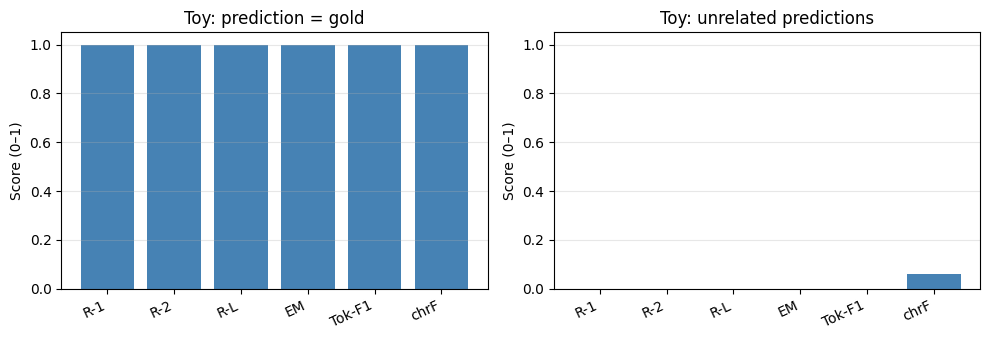

In [ ]:
refs_toy = [
    "Summary judgment standard",
    "Discovery sanctions",
]
good_preds = list(refs_toy)
bad_preds = [
    "Weather report",
    "Totally unrelated heading",
]

agg_good = aggregate(good_preds, refs_toy)
agg_bad = aggregate(bad_preds, refs_toy)
print("Good:")
print_aggregate_metrics(agg_good)
print("Bad:")
print_aggregate_metrics(agg_bad)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
plot_summary_bars(axes[0], agg_good, "Toy: prediction = gold")
plot_summary_bars(axes[1], agg_bad, "Toy: unrelated predictions")
plt.tight_layout()
plt.show()

## Dev split — gold vs cheap baseline

- **Gold-as-prediction:** sanity (scores should cluster high).
- **Baseline:** first ~14 tokens of the passage vs gold heading — expect lower overlap and useful spread for histograms.

In [ ]:
if not (os.getenv("HUGGINGFACE_HUB_TOKEN") or os.getenv("HF_TOKEN")):
    raise RuntimeError("Set HUGGINGFACE_HUB_TOKEN (or HF_TOKEN) in .env to load dev split.")

DEV_N = 80
dev_ds = materialize_head(load_arg_summ_split_streaming(SPLIT_DEV), DEV_N)
refs = [row[TARGET_COLUMN] for row in dev_ds]
gold_preds = list(refs)
base_preds = [cheap_baseline(row[SOURCE_COLUMN]) for row in dev_ds]

agg_gold = aggregate(gold_preds, refs)
agg_base = aggregate(base_preds, refs)

print("Gold-as-pred:")
print_aggregate_metrics(agg_gold)
print("Cheap baseline:")
print_aggregate_metrics(agg_base)

RANDOM_SAMPLE_K = 5
sources_dev = [row[SOURCE_COLUMN] for row in dev_ds]
print_random_metric_samples(
    base_preds,
    refs,
    agg_base,
    sources=sources_dev,
    k=min(RANDOM_SAMPLE_K, DEV_N),
    seed=42,
    title=f"Dev N={DEV_N}: cheap baseline — random samples",
)

Gold-as-pred:
{'n': 80,
 'rouge1_f': 1.0,
 'rouge2_f': 1.0,
 'rougeL_f': 1.0,
 'exact_match_rate': 1.0,
 'token_f1_macro': 1.0,
 'chrf_corpus': 1.0}
Cheap baseline:
{'n': 80,
 'rouge1_f': 0.2387,
 'rouge2_f': 0.0708,
 'rougeL_f': 0.1955,
 'exact_match_rate': 0.0,
 'token_f1_macro': 0.1929,
 'chrf_corpus': 0.2429}

--- Dev N=80: cheap baseline — random samples (5 of 80) ---

[1] idx=14
  passage: The First Amendment has long vouchsafed control 
over religious functions to religious groups  them-
selves.  That  protect s both religious groups' r ight to au-
tonomy and the government's duty not to control reli-
gious functions. Pet'r …
  gold:    The First Amendment protects religious groups' ability to control who performs important religious functions.
  pred:    The First Amendment has long vouchsafed control over religious functions to religious groups them-
  scores:  R1=0.643 R2=0.308 RL=0.429 EM=0 tokF1=0.500 chrF_s=0.553

[2] idx=3
  passage: Federal law illustrates some of the  t

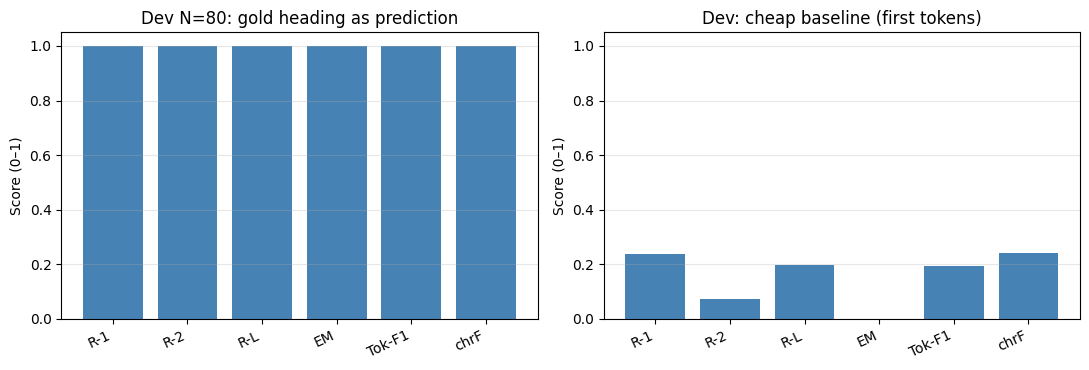

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
plot_summary_bars(axes[0], agg_gold, f"Dev N={DEV_N}: gold heading as prediction")
plot_summary_bars(axes[1], agg_base, "Dev: cheap baseline (first tokens)")
plt.tight_layout()
plt.show()

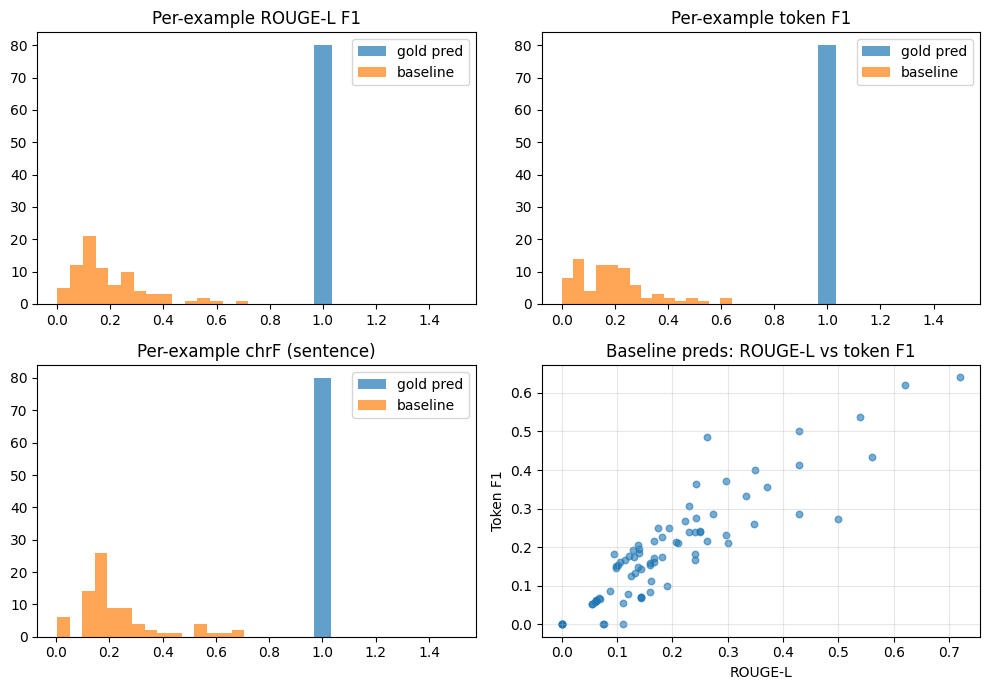

In [ ]:
pe_g = agg_gold["per_example"]
pe_b = agg_base["per_example"]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))

axes[0, 0].hist(pe_g["rougeL_f"], bins=15, alpha=0.7, label="gold pred", color="C0")
axes[0, 0].hist(pe_b["rougeL_f"], bins=15, alpha=0.7, label="baseline", color="C1")
axes[0, 0].set_title("Per-example ROUGE-L F1")
axes[0, 0].legend()

axes[0, 1].hist(pe_g["token_f1"], bins=15, alpha=0.7, label="gold pred", color="C0")
axes[0, 1].hist(pe_b["token_f1"], bins=15, alpha=0.7, label="baseline", color="C1")
axes[0, 1].set_title("Per-example token F1")
axes[0, 1].legend()

axes[1, 0].hist(pe_g["chrf"], bins=15, alpha=0.7, label="gold pred", color="C0")
axes[1, 0].hist(pe_b["chrf"], bins=15, alpha=0.7, label="baseline", color="C1")
axes[1, 0].set_title("Per-example chrF (sentence)")
axes[1, 0].legend()

ax = axes[1, 1]
ax.scatter(pe_b["rougeL_f"], pe_b["token_f1"], alpha=0.6, s=22)
ax.set_xlabel("ROUGE-L")
ax.set_ylabel("Token F1")
ax.set_title("Baseline preds: ROUGE-L vs token F1")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Scratch seq2seq — metrics **from saved inference**

**JSON:** **[`06_inference_scratch_runs.ipynb`](06_inference_scratch_runs.ipynb)** writes `artifacts/inference_runs/{split}_scratch_{tiny|small|medium}.json` (preds, refs, sources, full `aggregate`). Match **`EVAL_SPLIT`** / **`EVAL_N`** here to the saved run.

These cells **only load** those files — no model. LLM-as-judge: **[`08_llm_judge.ipynb`](08_llm_judge.ipynb)**.

**Report figures:** the following section shows a **corpus metrics table** (dev/test × presets), then plots — dev vs test bars, per-example histograms, and a scatter — from the same JSON. Run that cell for grader-friendly output.

Use the **Inference viewer** cell further below to inspect examples interactively.


In [ ]:
from briefme.data import SPLIT_DEV, SPLIT_TEST
from briefme.inference_persist import load_inference_json, scratch_inference_json_path

# --- match 06_inference_scratch_runs.ipynb ---
EVAL_SPLIT = SPLIT_DEV  # or SPLIT_TEST
EVAL_N = 30
RANDOM_SAMPLE_K = 5

split_tag = "dev" if EVAL_SPLIT == SPLIT_DEV else "test"

for label in ("tiny", "small", "medium"):
    load_path = scratch_inference_json_path(REPO_ROOT, split_tag=split_tag, label=label)
    if not load_path.is_file():
        print(f"[skip] no saved inference at {load_path} — run 06_inference_scratch_runs.ipynb")
        continue
    data = load_inference_json(load_path)
    preds = data["preds"]
    refs = data["refs"]
    sources = data["sources"]
    agg = data["aggregate"]
    print(f"\n=== {split_tag} · scratch {label} ({load_path.relative_to(REPO_ROOT)}) ===")
    print(f"checkpoint (saved): {data['checkpoint']}")
    if data.get("split_tag") != split_tag:
        print(f"[warn] JSON split_tag={data.get('split_tag')} != {split_tag}")
    if int(data.get("eval_n", -1)) != EVAL_N:
        print(f"[warn] JSON eval_n={data.get('eval_n')} != EVAL_N={EVAL_N}")
    print_aggregate_metrics(agg)
    print_random_metric_samples(
        preds,
        refs,
        agg,
        sources=sources,
        k=min(RANDOM_SAMPLE_K, len(preds)),
        seed=42,
        title=f"{split_tag} · scratch {label}",
    )



=== dev · scratch tiny (artifacts/inference_runs/dev_scratch_tiny.json) ===
checkpoint (saved): /Users/naataaniitsosie/repos/cs474/runs/notebook_scratch_tiny_full/best.pt
[warn] JSON eval_n=2319 != EVAL_N=30
{'n': 2319,
 'rouge1_f': 0.1125,
 'rouge2_f': 0.0108,
 'rougeL_f': 0.0988,
 'exact_match_rate': 0.0,
 'token_f1_macro': 0.0967,
 'chrf_corpus': 0.3689}

--- dev · scratch tiny (5 of 2319) ---

[1] idx=456
  passage: As discussed above, the relevant question under 
this Court's post- Hall decisions is whether the "the 
plan of the Convention" " altered " the immunity that 
States enjoyed before ratification, Alden , 527 U.S. at 
713 (emphasis added)—not…
  gold:    The Constitution did not abrogate States' immunity from suit in each other's courts
  pred:    The Court's text of the a "rement Clauses a "rement" and the a "rement"
  scores:  R1=0.207 R2=0.000 RL=0.138 EM=0 tokF1=0.074 chrF_s=0.167

[2] idx=102
  passage: Even though colleges and universities have 
legitimate reasons 

## Report figures (saved inference JSON)

Loads **`artifacts/inference_runs/{dev|test}_scratch_{tiny|small|medium}.json`** produced by **`06_inference_scratch_runs.ipynb`**.

**Table:** corpus-level ROUGE-1 / ROUGE-L / Tok F1 / chrF / EM for each split × preset (missing JSON rows show em dashes).

**Plots:** same metrics as **dev vs test** grouped bars, **histograms** of per-example ROUGE-L, token-F1 for **medium**, and a **scatter** (ROUGE-L vs Tok F1 on dev/medium).

Re-run **`06`** for missing splits so bars/histograms are complete.


Split,Preset,n,ROUGE-1,ROUGE-L,Tok F1 (macro),chrF (corpus),EM,Checkpoint
dev,tiny,2319,0.1125,0.0988,0.0967,0.3689,0.0000,best.pt
dev,small,2319,0.1429,0.1289,0.1311,0.3854,0.0000,best.pt
dev,medium,2319,0.0854,0.0771,0.0731,0.1906,0.0000,best.pt
test,tiny,—,—,—,—,—,—,(no JSON)
test,small,—,—,—,—,—,—,(no JSON)
test,medium,—,—,—,—,—,—,(no JSON)


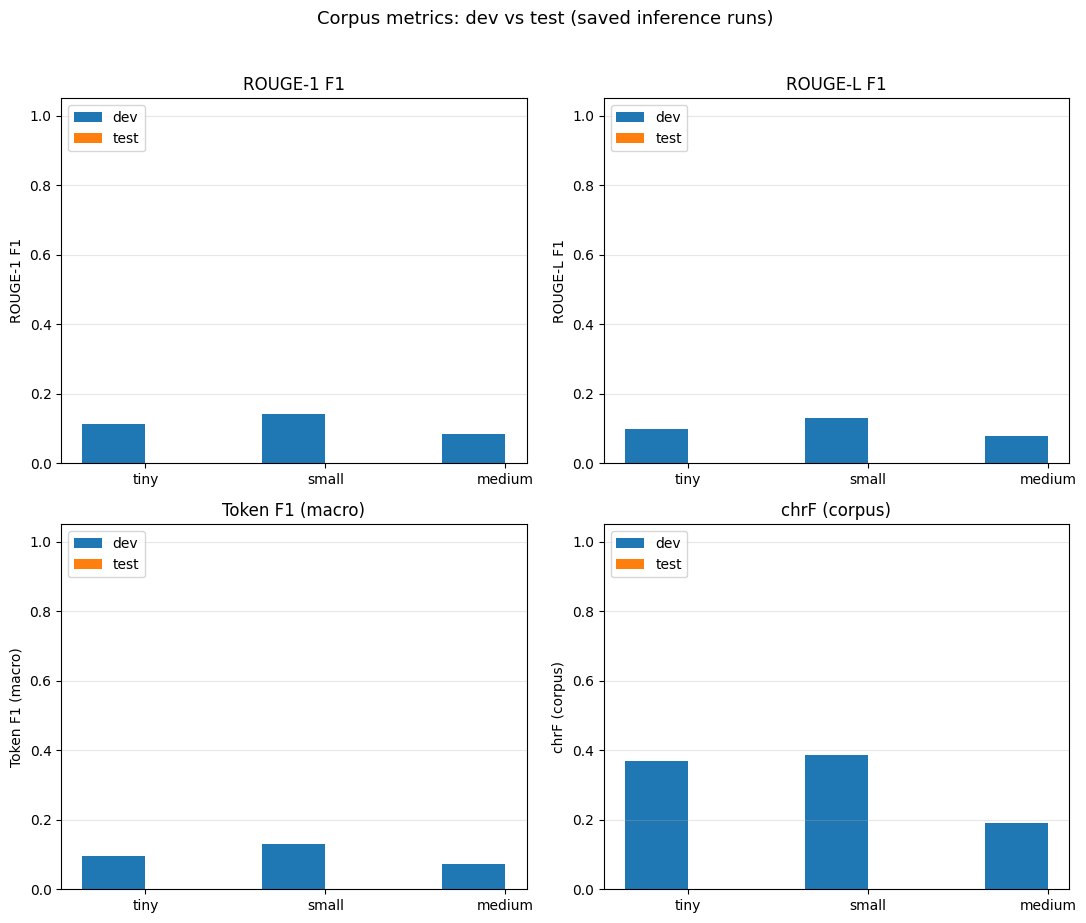

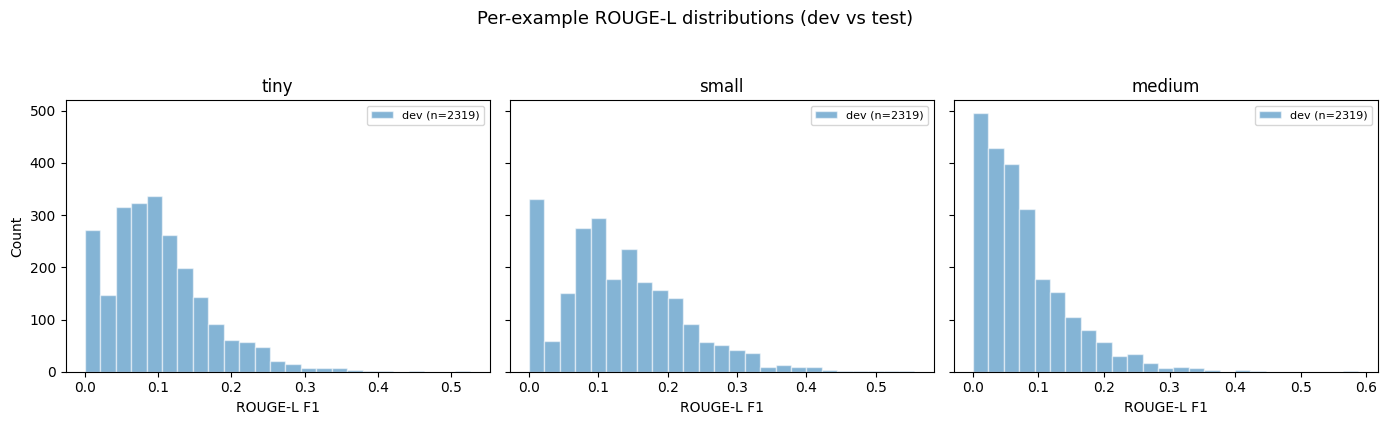

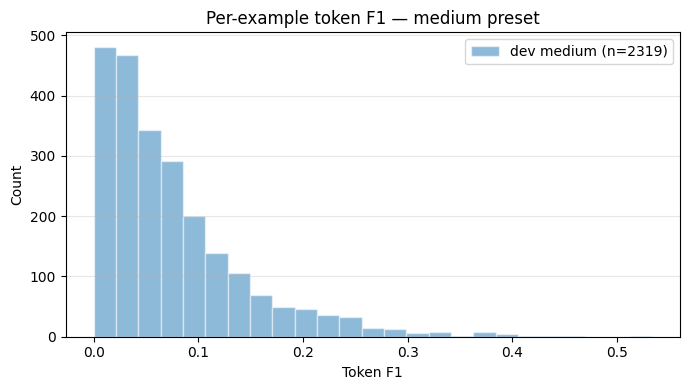

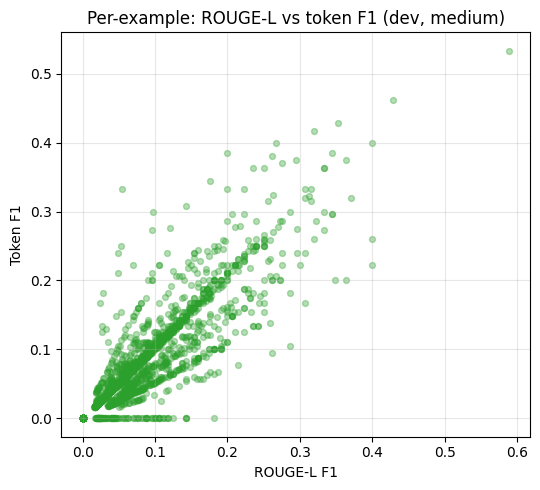

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

from IPython.display import HTML, display

from briefme.inference_persist import inference_runs_dir, load_inference_json

RUN_DIR = inference_runs_dir(REPO_ROOT)
LABELS = ("tiny", "small", "medium")
SPLITS = ("dev", "test")


def load_run(split_tag: str, label: str):
    p = RUN_DIR / f"{split_tag}_scratch_{label}.json"
    if not p.is_file():
        return None
    return load_inference_json(p)


# --- Corpus summary table (aggregate metrics from saved JSON) ---
_rows: list[str] = []
for st in SPLITS:
    for lab in LABELS:
        d = load_run(st, lab)
        if d is None:
            _rows.append(
                "<tr>"
                f"<td>{st}</td><td>{lab}</td>"
                "<td>—</td><td>—</td><td>—</td><td>—</td><td>—</td><td>—</td>"
                "<td><em>(no JSON)</em></td>"
                "</tr>"
            )
            continue
        a = d["aggregate"]
        ck = Path(d["checkpoint"]).name
        _rows.append(
            "<tr>"
            f"<td>{st}</td><td>{lab}</td>"
            f"<td style=\"text-align:right\">{int(a['n'])}</td>"
            f"<td style=\"text-align:right\">{float(a['rouge1_f']):.4f}</td>"
            f"<td style=\"text-align:right\">{float(a['rougeL_f']):.4f}</td>"
            f"<td style=\"text-align:right\">{float(a['token_f1_macro']):.4f}</td>"
            f"<td style=\"text-align:right\">{float(a['chrf_corpus']):.4f}</td>"
            f"<td style=\"text-align:right\">{float(a['exact_match_rate']):.4f}</td>"
            f"<td style=\"font-size:12px\">{ck}</td>"
            "</tr>"
        )

_corpus_html = (
    "<style>"
    ".bm-corpus { border-collapse: collapse; font-size: 14px; margin: 0.5em 0 1.2em; } "
    ".bm-corpus th, .bm-corpus td { border: 1px solid #ccc; padding: 6px 10px; } "
    ".bm-corpus th { background: #f4f4f4; text-align: left; } "
    "</style>"
    "<p><strong>Corpus metrics</strong> (aggregate from <code>artifacts/inference_runs/</code> JSON)</p>"
    '<table class="bm-corpus"><thead><tr>'
    "<th>Split</th><th>Preset</th><th>n</th>"
    "<th>ROUGE-1</th><th>ROUGE-L</th><th>Tok F1 (macro)</th><th>chrF (corpus)</th><th>EM</th>"
    "<th>Checkpoint</th>"
    "</tr></thead><tbody>"
    + "".join(_rows)
    + "</tbody></table>"
)
display(HTML(_corpus_html))

# --- Figure 1: corpus metrics, dev vs test grouped by preset ---
METRICS = [
    ("rouge1_f", "ROUGE-1 F1"),
    ("rougeL_f", "ROUGE-L F1"),
    ("token_f1_macro", "Token F1 (macro)"),
    ("chrf_corpus", "chrF (corpus)"),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, (mkey, mtitle) in zip(axes.flat, METRICS):
    dev_vals, test_vals = [], []
    for lab in LABELS:
        dd, dt = load_run("dev", lab), load_run("test", lab)
        dev_vals.append(float(dd["aggregate"][mkey]) if dd is not None else np.nan)
        test_vals.append(float(dt["aggregate"][mkey]) if dt is not None else np.nan)
    x = np.arange(len(LABELS))
    w = 0.35
    ax.bar(x - w / 2, dev_vals, w, label="dev", color="C0")
    ax.bar(x + w / 2, test_vals, w, label="test", color="C1")
    ax.set_xticks(x)
    ax.set_xticklabels(LABELS)
    ax.set_ylabel(mtitle)
    ax.set_title(mtitle)
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Corpus metrics: dev vs test (saved inference runs)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# --- Figure 2: per-example ROUGE-L histograms (dev vs test), one column per preset ---
fig2, axes2 = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, lab in zip(axes2, LABELS):
    dd, dt = load_run("dev", lab), load_run("test", lab)
    if dd is not None:
        rl = dd["aggregate"]["per_example"]["rougeL_f"]
        nb = min(25, max(10, len(rl) // 5))
        ax.hist(rl, bins=nb, alpha=0.55, label=f"dev (n={len(rl)})", color="C0", edgecolor="white")
    if dt is not None:
        rl = dt["aggregate"]["per_example"]["rougeL_f"]
        nb = min(25, max(10, len(rl) // 5))
        ax.hist(rl, bins=nb, alpha=0.55, label=f"test (n={len(rl)})", color="C1", edgecolor="white")
    ax.set_title(lab)
    ax.set_xlabel("ROUGE-L F1")
    ax.legend(fontsize=8)
axes2[0].set_ylabel("Count")
fig2.suptitle("Per-example ROUGE-L distributions (dev vs test)", fontsize=13, y=1.05)
plt.tight_layout()
plt.show()

# --- Figure 3: token F1 per-example (medium) ---
fig3, ax3 = plt.subplots(figsize=(7, 4))
for st, c in zip(SPLITS, ("C0", "C1")):
    d = load_run(st, "medium")
    if d is None:
        continue
    tf = d["aggregate"]["per_example"]["token_f1"]
    nb = min(25, max(10, len(tf) // 5))
    ax3.hist(tf, bins=nb, alpha=0.5, label=f"{st} medium (n={len(tf)})", color=c, edgecolor="white")
ax3.set_xlabel("Token F1")
ax3.set_ylabel("Count")
ax3.set_title("Per-example token F1 — medium preset")
ax3.legend()
ax3.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# --- Figure 4: scatter ROUGE-L vs token F1 (medium, dev) ---
dd = load_run("dev", "medium")
if dd is not None:
    pe = dd["aggregate"]["per_example"]
    rlv, tfv = pe["rougeL_f"], pe["token_f1"]
    fig4, ax4 = plt.subplots(figsize=(5.5, 5))
    ax4.scatter(rlv, tfv, alpha=0.35, s=18, c="C2")
    ax4.set_xlabel("ROUGE-L F1")
    ax4.set_ylabel("Token F1")
    ax4.set_title("Per-example: ROUGE-L vs token F1 (dev, medium)")
    ax4.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("[skip] scatter: no dev_scratch_medium.json")


## Inference viewer (saved JSON)

Uses JSON under `artifacts/inference_runs/` (or set `VIEW_RUNS_DIR` in the cell to e.g. `artifacts/inference_runs_greedy`) produced by **`06_inference_scratch_runs.ipynb`**. Set `VIEW_SPLIT` to match the split you saved (`SPLIT_DEV` vs `SPLIT_TEST`). The widgets show **all automated per-row metrics** from `aggregate.per_example` (ROUGE-1/2/L, exact match, token F1, sentence chrF), plus passage / gold / pred. Slider is **0-based index**; the header also shows **1-based row**. Re-run **only this cell** to browse interactively (requires `ipywidgets`; install with `pip install ipywidgets` if needed).

In [ ]:
from IPython.display import HTML, clear_output, display

from briefme.data import SPLIT_DEV, SPLIT_TEST
from briefme.inference_persist import inference_runs_dir, load_inference_json

VIEW_SPLIT = SPLIT_DEV  # match EVAL_SPLIT from the scratch inference cell
# Default: artifacts/inference_runs. Use e.g. REPO_ROOT / "artifacts" / "inference_runs_greedy" for greedy JSON.
VIEW_RUNS_DIR = inference_runs_dir(REPO_ROOT)

split_tag = "dev" if VIEW_SPLIT == SPLIT_DEV else "test"
paths = sorted(VIEW_RUNS_DIR.glob(f"{split_tag}_scratch_*.json")) if VIEW_RUNS_DIR.is_dir() else []

_METRIC_ROWS = (
    ("rouge1_f", "ROUGE-1 F1"),
    ("rouge2_f", "ROUGE-2 F1"),
    ("rougeL_f", "ROUGE-L F1"),
    ("exact_match", "Exact match"),
    ("token_f1", "Token F1"),
    ("chrf", "chrF (sentence)"),
)


def _metrics_table_html(pe: dict, i: int) -> str:
    body = []
    for key, title in _METRIC_ROWS:
        v = float(pe[key][i])
        body.append(
            f"<tr><td>{title}</td>"
            f"<td style='text-align:right;font-variant-numeric:tabular-nums'>{v:.12g}</td></tr>"
        )
    return (
        "<table class='bm-pe' style='border-collapse:collapse;margin:0.4em 0;font-size:14px'>"
        "<style>.bm-pe td,.bm-pe th{border:1px solid #ccc;padding:4px 10px}"
        ".bm-pe th{background:#f4f4f4;text-align:left}</style>"
        "<thead><tr><th colspan='2'>Automated metrics (<code>aggregate.per_example</code>)</th></tr></thead>"
        "<tbody>" + "".join(body) + "</tbody></table>"
    )


if not paths:
    print(
        f"No JSON files in {VIEW_RUNS_DIR} for '{split_tag}_scratch_*.json'. "
        "Run the scratch inference cell first."
    )
else:
    run_options = {p.stem: load_inference_json(p) for p in paths}
    print("Available:", ", ".join(run_options.keys()))

    try:
        import ipywidgets as widgets

        dd = widgets.Dropdown(
            options=list(run_options.keys()),
            description="Run:",
            layout=widgets.Layout(width="min(95%, 560px)"),
        )
        first_n = int(next(iter(run_options.values()))["aggregate"]["n"])
        idx_w = widgets.IntSlider(
            value=0,
            min=0,
            max=max(0, first_n - 1),
            step=1,
            description="index (0-based)",
            layout=widgets.Layout(width="420px"),
        )
        out = widgets.Output()

        def _sync_slider_max(_=None) -> None:
            data = run_options[dd.value]
            n = int(data["aggregate"]["n"])
            idx_w.max = max(0, n - 1)
            if idx_w.value > idx_w.max:
                idx_w.value = idx_w.max

        def _show(_=None) -> None:
            data = run_options[dd.value]
            preds, refs, sources = data["preds"], data["refs"], data["sources"]
            pe = data["aggregate"]["per_example"]
            i = int(idx_w.value)
            row_1 = i + 1
            with out:
                clear_output(wait=True)
                display(
                    HTML(
                        f"<p><strong>Row {row_1}</strong> (1-based) · "
                        f"<strong>index {i}</strong> (0-based)</p>"
                    )
                )
                display(HTML(_metrics_table_html(pe, i)))
                src = sources[i]
                preview = (src[:2400] + "\n… [truncated]") if len(src) > 2400 else src
                print(f"checkpoint: {data['checkpoint']}")
                print(f"eval_n={data['eval_n']}  label={data['label']}  split={data['split_tag']}\n")
                print(f"[{i}] passage:\n{preview}\n")
                print(f"gold: {refs[i]}\n")
                print(f"pred: {preds[i]}\n")

        def _on_run_change(_=None) -> None:
            _sync_slider_max()
            _show()

        dd.observe(_on_run_change, names="value")
        idx_w.observe(_show, names="value")

        _on_run_change()
        display(dd, idx_w, out)
    except ImportError:
        stem = paths[0].stem
        d0 = run_options[stem]
        print("ipywidgets not installed; showing index 0 of first run only.")
        pe = d0["aggregate"]["per_example"]
        i = 0
        display(HTML("<p><strong>Row 1</strong> (1-based) · <strong>index 0</strong> (0-based)</p>"))
        display(HTML(_metrics_table_html(pe, i)))
        print(f"checkpoint: {d0['checkpoint']}\n")
        print(f"[{i}] passage:\n{d0['sources'][i][:1200]}…\n")
        print(f"gold: {d0['refs'][i]}\npred: {d0['preds'][i]}")

Available: dev_scratch_medium, dev_scratch_small, dev_scratch_tiny


Dropdown(description='Run:', layout=Layout(width='min(95%, 560px)'), options=('dev_scratch_medium', 'dev_scrat…

IntSlider(value=0, description='index (0-based)', layout=Layout(width='420px'), max=2318)

Output()

### Optional: beam / custom inference folder

Greedy decoding metrics use **`artifacts/inference_runs/`** in the cells **above** (unchanged).

If **`06_inference_scratch_runs.ipynb`** wrote beam or other runs under e.g. **`artifacts/inference_runs_beam4/`**, set **`SCRATCH_RUNS_SUBDIR`** in the next cell to match **`06`**, then run the following cells for per-run prints, corpus table, figures, and interactive viewer on that folder.

In [ ]:
# Folder name under ``artifacts/`` (must match ``06``, e.g. ``inference_runs_beam4``).
SCRATCH_RUNS_SUBDIR = "inference_runs_beam4"

from briefme.inference_persist import scratch_runs_artifacts_dir

RUN_DIR = scratch_runs_artifacts_dir(REPO_ROOT, artifacts_subdir=SCRATCH_RUNS_SUBDIR)
print(f"[optional subdir] inference dir: {RUN_DIR.relative_to(REPO_ROOT)}", flush=True)

ImportError: cannot import name 'scratch_runs_artifacts_dir' from 'briefme.inference_persist' (/Users/naataaniitsosie/repos/cs474/src/briefme/inference_persist.py)

In [ ]:
from briefme.data import SPLIT_DEV, SPLIT_TEST
from briefme.inference_persist import load_inference_json, scratch_inference_json_path

# --- match 06_inference_scratch_runs.ipynb ---
EVAL_SPLIT = SPLIT_DEV  # or SPLIT_TEST
EVAL_N = 30
RANDOM_SAMPLE_K = 5

split_tag = "dev" if EVAL_SPLIT == SPLIT_DEV else "test"

for label in ("tiny", "small", "medium"):
    load_path = scratch_inference_json_path(REPO_ROOT, split_tag=split_tag, label=label, artifacts_subdir=SCRATCH_RUNS_SUBDIR)
    if not load_path.is_file():
        print(f"[skip] no saved inference at {load_path} — run 06_inference_scratch_runs.ipynb")
        continue
    data = load_inference_json(load_path)
    preds = data["preds"]
    refs = data["refs"]
    sources = data["sources"]
    agg = data["aggregate"]
    print(f"\n=== {split_tag} · scratch {label} ({load_path.relative_to(REPO_ROOT)}) ===")
    print(f"checkpoint (saved): {data['checkpoint']}")
    if data.get("split_tag") != split_tag:
        print(f"[warn] JSON split_tag={data.get('split_tag')} != {split_tag}")
    if int(data.get("eval_n", -1)) != EVAL_N:
        print(f"[warn] JSON eval_n={data.get('eval_n')} != EVAL_N={EVAL_N}")
    print_aggregate_metrics(agg)
    print_random_metric_samples(
        preds,
        refs,
        agg,
        sources=sources,
        k=min(RANDOM_SAMPLE_K, len(preds)),
        seed=42,
        title=f"{split_tag} · scratch {label}",
    )


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

from IPython.display import HTML, display

from briefme.inference_persist import load_inference_json, scratch_runs_artifacts_dir

RUN_DIR = scratch_runs_artifacts_dir(REPO_ROOT, artifacts_subdir=SCRATCH_RUNS_SUBDIR)
print(f"[metrics figures] inference dir: {RUN_DIR.relative_to(REPO_ROOT)}", flush=True)

LABELS = ("tiny", "small", "medium")
SPLITS = ("dev", "test")


def load_run(split_tag: str, label: str):
    p = RUN_DIR / f"{split_tag}_scratch_{label}.json"
    if not p.is_file():
        return None
    return load_inference_json(p)


# --- Corpus summary table (aggregate metrics from saved JSON) ---
_rows: list[str] = []
for st in SPLITS:
    for lab in LABELS:
        d = load_run(st, lab)
        if d is None:
            _rows.append(
                "<tr>"
                f"<td>{st}</td><td>{lab}</td>"
                "<td>—</td><td>—</td><td>—</td><td>—</td><td>—</td><td>—</td>"
                "<td><em>(no JSON)</em></td>"
                "</tr>"
            )
            continue
        a = d["aggregate"]
        ck = Path(d["checkpoint"]).name
        _rows.append(
            "<tr>"
            f"<td>{st}</td><td>{lab}</td>"
            f"<td style=\"text-align:right\">{int(a['n'])}</td>"
            f"<td style=\"text-align:right\">{float(a['rouge1_f']):.4f}</td>"
            f"<td style=\"text-align:right\">{float(a['rougeL_f']):.4f}</td>"
            f"<td style=\"text-align:right\">{float(a['token_f1_macro']):.4f}</td>"
            f"<td style=\"text-align:right\">{float(a['chrf_corpus']):.4f}</td>"
            f"<td style=\"text-align:right\">{float(a['exact_match_rate']):.4f}</td>"
            f"<td style=\"font-size:12px\">{ck}</td>"
            "</tr>"
        )

_corpus_html = (
    "<style>"
    ".bm-corpus { border-collapse: collapse; font-size: 14px; margin: 0.5em 0 1.2em; } "
    ".bm-corpus th, .bm-corpus td { border: 1px solid #ccc; padding: 6px 10px; } "
    ".bm-corpus th { background: #f4f4f4; text-align: left; } "
    "</style>"
    f"<p><strong>Corpus metrics</strong> (aggregate from <code>artifacts/{SCRATCH_RUNS_SUBDIR}/</code> JSON)</p>"
    '<table class="bm-corpus"><thead><tr>'
    "<th>Split</th><th>Preset</th><th>n</th>"
    "<th>ROUGE-1</th><th>ROUGE-L</th><th>Tok F1 (macro)</th><th>chrF (corpus)</th><th>EM</th>"
    "<th>Checkpoint</th>"
    "</tr></thead><tbody>"
    + "".join(_rows)
    + "</tbody></table>"
)
display(HTML(_corpus_html))

# --- Figure 1: corpus metrics, dev vs test grouped by preset ---
METRICS = [
    ("rouge1_f", "ROUGE-1 F1"),
    ("rougeL_f", "ROUGE-L F1"),
    ("token_f1_macro", "Token F1 (macro)"),
    ("chrf_corpus", "chrF (corpus)"),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, (mkey, mtitle) in zip(axes.flat, METRICS):
    dev_vals, test_vals = [], []
    for lab in LABELS:
        dd, dt = load_run("dev", lab), load_run("test", lab)
        dev_vals.append(float(dd["aggregate"][mkey]) if dd is not None else np.nan)
        test_vals.append(float(dt["aggregate"][mkey]) if dt is not None else np.nan)
    x = np.arange(len(LABELS))
    w = 0.35
    ax.bar(x - w / 2, dev_vals, w, label="dev", color="C0")
    ax.bar(x + w / 2, test_vals, w, label="test", color="C1")
    ax.set_xticks(x)
    ax.set_xticklabels(LABELS)
    ax.set_ylabel(mtitle)
    ax.set_title(mtitle)
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Corpus metrics: dev vs test (saved inference runs)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# --- Figure 2: per-example ROUGE-L histograms (dev vs test), one column per preset ---
fig2, axes2 = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, lab in zip(axes2, LABELS):
    dd, dt = load_run("dev", lab), load_run("test", lab)
    if dd is not None:
        rl = dd["aggregate"]["per_example"]["rougeL_f"]
        nb = min(25, max(10, len(rl) // 5))
        ax.hist(rl, bins=nb, alpha=0.55, label=f"dev (n={len(rl)})", color="C0", edgecolor="white")
    if dt is not None:
        rl = dt["aggregate"]["per_example"]["rougeL_f"]
        nb = min(25, max(10, len(rl) // 5))
        ax.hist(rl, bins=nb, alpha=0.55, label=f"test (n={len(rl)})", color="C1", edgecolor="white")
    ax.set_title(lab)
    ax.set_xlabel("ROUGE-L F1")
    ax.legend(fontsize=8)
axes2[0].set_ylabel("Count")
fig2.suptitle("Per-example ROUGE-L distributions (dev vs test)", fontsize=13, y=1.05)
plt.tight_layout()
plt.show()

# --- Figure 3: token F1 per-example (medium) ---
fig3, ax3 = plt.subplots(figsize=(7, 4))
for st, c in zip(SPLITS, ("C0", "C1")):
    d = load_run(st, "medium")
    if d is None:
        continue
    tf = d["aggregate"]["per_example"]["token_f1"]
    nb = min(25, max(10, len(tf) // 5))
    ax3.hist(tf, bins=nb, alpha=0.5, label=f"{st} medium (n={len(tf)})", color=c, edgecolor="white")
ax3.set_xlabel("Token F1")
ax3.set_ylabel("Count")
ax3.set_title("Per-example token F1 — medium preset")
ax3.legend()
ax3.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# --- Figure 4: scatter ROUGE-L vs token F1 (medium, dev) ---
dd = load_run("dev", "medium")
if dd is not None:
    pe = dd["aggregate"]["per_example"]
    rlv, tfv = pe["rougeL_f"], pe["token_f1"]
    fig4, ax4 = plt.subplots(figsize=(5.5, 5))
    ax4.scatter(rlv, tfv, alpha=0.35, s=18, c="C2")
    ax4.set_xlabel("ROUGE-L F1")
    ax4.set_ylabel("Token F1")
    ax4.set_title("Per-example: ROUGE-L vs token F1 (dev, medium)")
    ax4.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("[skip] scatter: no dev_scratch_medium.json")


In [ ]:
from IPython.display import HTML, clear_output, display

from briefme.data import SPLIT_DEV, SPLIT_TEST
from briefme.inference_persist import load_inference_json, scratch_runs_artifacts_dir

VIEW_SPLIT = SPLIT_DEV  # match EVAL_SPLIT from the scratch inference cell
# Must match ``SCRATCH_RUNS_SUBDIR`` in the setup cell (greedy ``inference_runs``; beam ``inference_runs_beam4``, etc.).
VIEW_RUNS_DIR = scratch_runs_artifacts_dir(REPO_ROOT, artifacts_subdir=SCRATCH_RUNS_SUBDIR)

split_tag = "dev" if VIEW_SPLIT == SPLIT_DEV else "test"
paths = sorted(VIEW_RUNS_DIR.glob(f"{split_tag}_scratch_*.json")) if VIEW_RUNS_DIR.is_dir() else []

_METRIC_ROWS = (
    ("rouge1_f", "ROUGE-1 F1"),
    ("rouge2_f", "ROUGE-2 F1"),
    ("rougeL_f", "ROUGE-L F1"),
    ("exact_match", "Exact match"),
    ("token_f1", "Token F1"),
    ("chrf", "chrF (sentence)"),
)


def _metrics_table_html(pe: dict, i: int) -> str:
    body = []
    for key, title in _METRIC_ROWS:
        v = float(pe[key][i])
        body.append(
            f"<tr><td>{title}</td>"
            f"<td style='text-align:right;font-variant-numeric:tabular-nums'>{v:.12g}</td></tr>"
        )
    return (
        "<table class='bm-pe' style='border-collapse:collapse;margin:0.4em 0;font-size:14px'>"
        "<style>.bm-pe td,.bm-pe th{border:1px solid #ccc;padding:4px 10px}"
        ".bm-pe th{background:#f4f4f4;text-align:left}</style>"
        "<thead><tr><th colspan='2'>Automated metrics (<code>aggregate.per_example</code>)</th></tr></thead>"
        "<tbody>" + "".join(body) + "</tbody></table>"
    )


if not paths:
    print(
        f"No JSON files in {VIEW_RUNS_DIR} for '{split_tag}_scratch_*.json'. "
        "Run the scratch inference cell first."
    )
else:
    run_options = {p.stem: load_inference_json(p) for p in paths}
    print("Available:", ", ".join(run_options.keys()))

    try:
        import ipywidgets as widgets

        dd = widgets.Dropdown(
            options=list(run_options.keys()),
            description="Run:",
            layout=widgets.Layout(width="min(95%, 560px)"),
        )
        first_n = int(next(iter(run_options.values()))["aggregate"]["n"])
        idx_w = widgets.IntSlider(
            value=0,
            min=0,
            max=max(0, first_n - 1),
            step=1,
            description="index (0-based)",
            layout=widgets.Layout(width="420px"),
        )
        out = widgets.Output()

        def _sync_slider_max(_=None) -> None:
            data = run_options[dd.value]
            n = int(data["aggregate"]["n"])
            idx_w.max = max(0, n - 1)
            if idx_w.value > idx_w.max:
                idx_w.value = idx_w.max

        def _show(_=None) -> None:
            data = run_options[dd.value]
            preds, refs, sources = data["preds"], data["refs"], data["sources"]
            pe = data["aggregate"]["per_example"]
            i = int(idx_w.value)
            row_1 = i + 1
            with out:
                clear_output(wait=True)
                display(
                    HTML(
                        f"<p><strong>Row {row_1}</strong> (1-based) · "
                        f"<strong>index {i}</strong> (0-based)</p>"
                    )
                )
                display(HTML(_metrics_table_html(pe, i)))
                src = sources[i]
                preview = (src[:2400] + "\n… [truncated]") if len(src) > 2400 else src
                print(f"checkpoint: {data['checkpoint']}")
                print(f"eval_n={data['eval_n']}  label={data['label']}  split={data['split_tag']}\n")
                print(f"[{i}] passage:\n{preview}\n")
                print(f"gold: {refs[i]}\n")
                print(f"pred: {preds[i]}\n")

        def _on_run_change(_=None) -> None:
            _sync_slider_max()
            _show()

        dd.observe(_on_run_change, names="value")
        idx_w.observe(_show, names="value")

        _on_run_change()
        display(dd, idx_w, out)
    except ImportError:
        stem = paths[0].stem
        d0 = run_options[stem]
        print("ipywidgets not installed; showing index 0 of first run only.")
        pe = d0["aggregate"]["per_example"]
        i = 0
        display(HTML("<p><strong>Row 1</strong> (1-based) · <strong>index 0</strong> (0-based)</p>"))
        display(HTML(_metrics_table_html(pe, i)))
        print(f"checkpoint: {d0['checkpoint']}\n")
        print(f"[{i}] passage:\n{d0['sources'][i][:1200]}…\n")
        print(f"gold: {d0['refs'][i]}\npred: {d0['preds'][i]}")
